<a href="https://colab.research.google.com/github/GargEngineers7002/neural_networks_from_scratch/blob/main/mnist_digit_recognizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kagglehub
import kagglehub
import pandas as pd
kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [3]:
path = kagglehub.competition_download("digit-recognizer")
print("path to dataset:", path)

100%|██████████| 15.3M/15.3M [00:00<00:00, 91.9MB/s]

Extracting files...


path to dataset: /root/.cache/kagglehub/competitions/digit-recognizer


In [4]:
import matplotlib.pyplot as plt

df=pd.read_csv(f"{path}/train.csv")
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
import numpy as np

df=np.array(df)
m,n=df.shape
np.random.shuffle(df)

df_val=df[0:1000].T
y_val=df_val[0]
x_val=df_val[1:n]
x_val=x_val/255

df_train=df[1000:m].T
y_train=df_train[0]
x_train=df_train[1:n]
x_train=x_train/255
_,m_train=df_train.shape

In [6]:
print(x_train.shape)

(784, 41000)


In [7]:
def init_params():
  w1=np.random.rand(10,784)-0.5
  b1=np.random.rand(10,1)-0.5
  w2=np.random.rand(10,10)-0.5
  b2=np.random.rand(10,1)-0.5
  return w1,b1,w2,b2

def relu(z):
  return np.maximum(z,0)

def softmax(z):
  return np.exp(z)/sum(np.exp(z))

def forward_prop(x,w1,b1,w2,b2):
  z1=w1.dot(x)+b1
  A1=relu(z1)
  z2=w2.dot(A1)+b2
  A2=softmax(z2)
  return z1,A1,z2,A2

def relu_deriv(z):
  return z>0

def one_hot(y):
  one_hot_y=np.zeros((y.size,y.max()+1))
  one_hot_y[np.arange(y.size),y]=1
  one_hot_y=one_hot_y.T
  return one_hot_y

def back_prop(a1,a2,x,y,w1,z1,w2,z2):
  one_hot_y=one_hot(y)
  dz2=a2-one_hot_y
  dw2=1/m*dz2.dot(a1.T)
  db2=1/m*np.sum(dz2)
  dz1=w2.T.dot(dz2)*relu_deriv(z1)
  dw1=1/m*dz1.dot(x.T)
  db1=1/m*np.sum(dz1)
  return dw1,db1,dw2,db2

def update_params(w1,b1,w2,b2,dw1,db1,dw2,db2, alpha):
  w1-=alpha*dw1
  b1-=alpha*db1
  w2-=alpha*dw2
  b2-=alpha*db2
  return w1,b1,w2,b2

In [8]:
def get_pred(a2):
  return np.argmax(a2,0)

def get_accuracy(pred, y):
  print(pred,y)
  return np.sum(pred==y)/y.size

def gradient_descent(x,y,alpha,iter):
  w1,b1,w2,b2=init_params()
  for i in range(iter):
    z1,a1,z2,a2=forward_prop(x,w1,b1,w2,b2)
    dw1,db1,dw2,db2=back_prop(a1,a2,x,y,w1,z1,w2,z2)
    w1,b1,w2,b2=update_params(w1,b1,w2,b2,dw1,db1,dw2,db2,alpha)
    if i%10==0:
      print("Iteration:", i)
      pred=get_pred(a2)
      print(get_accuracy(pred,y))
  return w1,b1,w2,b2

In [9]:
w1,b1,w2,b2=gradient_descent(x_train,y_train,0.10,1000)

Iteration: 0
[2 2 2 ... 2 0 0] [7 6 1 ... 9 7 9]
0.08487804878048781
Iteration: 10
[7 2 2 ... 2 5 0] [7 6 1 ... 9 7 9]
0.13063414634146342
Iteration: 20
[7 2 2 ... 2 2 0] [7 6 1 ... 9 7 9]
0.1828780487804878
Iteration: 30
[7 2 1 ... 2 2 0] [7 6 1 ... 9 7 9]
0.2677317073170732
Iteration: 40
[7 2 1 ... 1 0 0] [7 6 1 ... 9 7 9]
0.3026341463414634
Iteration: 50
[7 2 1 ... 1 0 0] [7 6 1 ... 9 7 9]
0.34026829268292685
Iteration: 60
[7 2 1 ... 1 0 0] [7 6 1 ... 9 7 9]
0.3880487804878049
Iteration: 70
[7 1 1 ... 1 0 0] [7 6 1 ... 9 7 9]
0.4259268292682927
Iteration: 80
[7 8 1 ... 1 0 0] [7 6 1 ... 9 7 9]
0.4591707317073171
Iteration: 90
[7 8 1 ... 1 0 0] [7 6 1 ... 9 7 9]
0.49729268292682927
Iteration: 100
[7 8 1 ... 8 0 0] [7 6 1 ... 9 7 9]
0.5332682926829269
Iteration: 110
[7 4 1 ... 8 0 0] [7 6 1 ... 9 7 9]
0.567170731707317
Iteration: 120
[7 4 1 ... 8 9 0] [7 6 1 ... 9 7 9]
0.5960243902439024
Iteration: 130
[7 6 1 ... 8 9 0] [7 6 1 ... 9 7 9]
0.6210975609756098
Iteration: 140
[7 6 1 ... 8 

In [10]:
def make_pred(x,w1,b1,w2,b2):
  _,_,_,a2=forward_prop(x,w1,b1,w2,b2)
  pred=get_pred(a2)
  return pred

def test_pred(idx,w1,b1,w2,b2):
  cur_image=x_train[:,idx,None]
  pred=make_pred(cur_image,w1,b1,w2,b2)
  label=y_train[idx]
  print("predictions: ", pred)
  print("Label: ", label)

  cur_image=cur_image.reshape((28,28))*255
  plt.gray()
  plt.imshow(cur_image, interpolation='nearest')
  plt.show()

predictions:  [7]
Label:  7


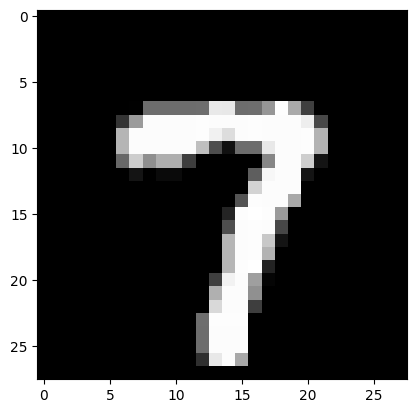

predictions:  [6]
Label:  6


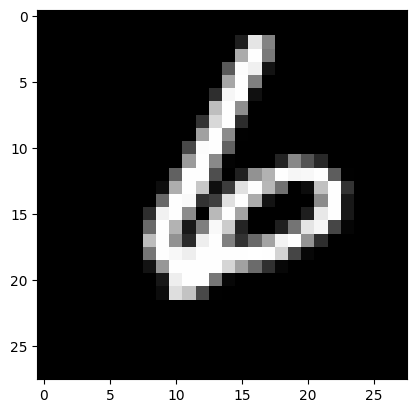

predictions:  [1]
Label:  1


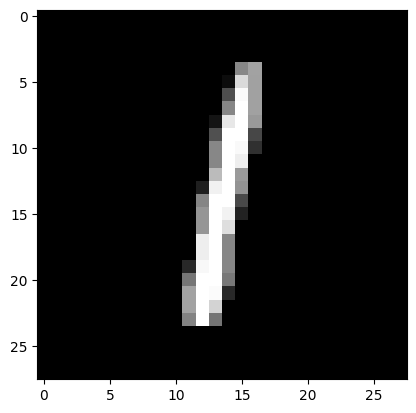

predictions:  [6]
Label:  6


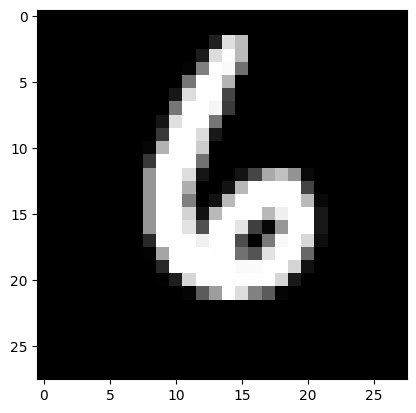

In [11]:
test_pred(0, w1, b1, w2, b2)
test_pred(1, w1, b1, w2, b2)
test_pred(2, w1, b1, w2, b2)
test_pred(3, w1, b1, w2, b2)

In [13]:
val_predictions=make_pred(x_val,w1,b1,w2,b2)
print(get_accuracy(val_predictions,y_val))

[2 3 9 1 1 4 1 8 1 5 6 5 6 4 0 2 7 7 0 9 4 5 9 2 7 0 6 8 2 8 3 8 1 1 1 9 9
 6 8 9 6 4 0 6 1 6 4 8 9 5 8 4 0 7 5 4 3 5 0 1 4 1 5 0 5 0 6 9 9 7 3 0 3 4
 6 1 5 1 5 5 5 2 8 8 2 3 1 5 1 5 5 6 1 3 0 3 1 8 1 6 2 2 7 6 3 5 7 8 2 7 7
 2 1 8 2 4 1 3 7 4 6 8 3 7 2 8 6 9 2 9 9 9 3 8 9 0 7 2 5 4 8 1 4 1 9 2 3 3
 7 8 0 1 7 2 8 0 9 7 6 6 7 8 6 6 5 4 6 3 3 5 5 2 0 3 0 7 7 5 7 0 4 4 3 4 8
 6 7 0 1 3 2 6 2 1 5 6 2 4 2 8 8 1 3 9 8 4 6 6 6 7 0 5 6 1 3 7 0 1 7 4 0 3
 3 0 3 1 6 1 7 4 2 1 0 2 2 3 6 5 3 1 4 1 3 1 1 2 3 0 2 7 2 3 2 2 9 5 0 7 3
 5 8 9 9 1 3 0 8 4 4 5 3 8 1 3 6 8 4 2 1 1 3 7 6 3 8 8 3 0 3 1 5 8 8 9 2 6
 3 6 2 0 8 3 2 8 8 3 8 4 1 2 1 6 3 2 4 9 9 7 1 1 4 2 8 2 2 7 8 0 1 9 9 2 0
 3 2 8 2 1 5 9 2 4 4 5 7 1 2 7 8 2 9 6 3 7 5 9 0 0 8 7 5 1 3 1 1 6 7 0 1 5
 7 1 6 2 8 5 3 7 2 5 1 7 4 1 6 6 4 4 3 6 6 0 0 9 9 6 4 4 0 9 1 2 3 2 3 7 8
 3 8 9 9 0 3 1 8 6 4 2 2 4 6 3 3 5 0 4 5 7 6 0 0 6 5 2 2 6 0 1 0 3 8 4 2 2
 5 3 7 1 6 7 2 9 1 2 1 9 0 0 2 3 3 5 3 9 7 3 7 9 8 7 8 3 3 7 5 4 9 3 5 2 6
 2 5 1 2 4 4 2 3 5 4 2 4 